### Import Libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    cross_validate, StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    classification_report
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

### Load Dataset

In [51]:
# Load directly from sklearn (same as UCI Breast Cancer Wisconsin)
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)           # 0 = Malignant, 1 = Benign

# Map to original labels for display
y_labels = pd.Series(data.target_names[data.target])

In [52]:
print(f"Total samples   : {X.shape[0]}")
print(f"Total features  : {X.shape[1]}")
print(f"\nFeature names:\n{list(data.feature_names)}")
print(f"\nClass distribution:")
for cls, name in enumerate(data.target_names):
    count = (y == cls).sum()
    print(f"  {name} ({cls}): {count} samples ({100*count/len(y):.1f}%)")

Total samples   : 569
Total features  : 30

Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

Class distribution:
  malignant (0): 212 samples (37.3%)
  benign (1): 357 samples (62.7%)


In [53]:
# SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
 
print(f"\nBasic Statistics:\n{X.describe().T[['mean','std','min','max']].round(3)}")
print(f"\nMissing values : {X.isnull().sum().sum()}")


Basic Statistics:
                            mean      std      min       max
mean radius               14.127    3.524    6.981    28.110
mean texture              19.290    4.301    9.710    39.280
mean perimeter            91.969   24.299   43.790   188.500
mean area                654.889  351.914  143.500  2501.000
mean smoothness            0.096    0.014    0.053     0.163
mean compactness           0.104    0.053    0.019     0.345
mean concavity             0.089    0.080    0.000     0.427
mean concave points        0.049    0.039    0.000     0.201
mean symmetry              0.181    0.027    0.106     0.304
mean fractal dimension     0.063    0.007    0.050     0.097
radius error               0.405    0.277    0.112     2.873
texture error              1.217    0.552    0.360     4.885
perimeter error            2.866    2.022    0.757    21.980
area error                40.337   45.491    6.802   542.200
smoothness error           0.007    0.003    0.002     0.031
compa

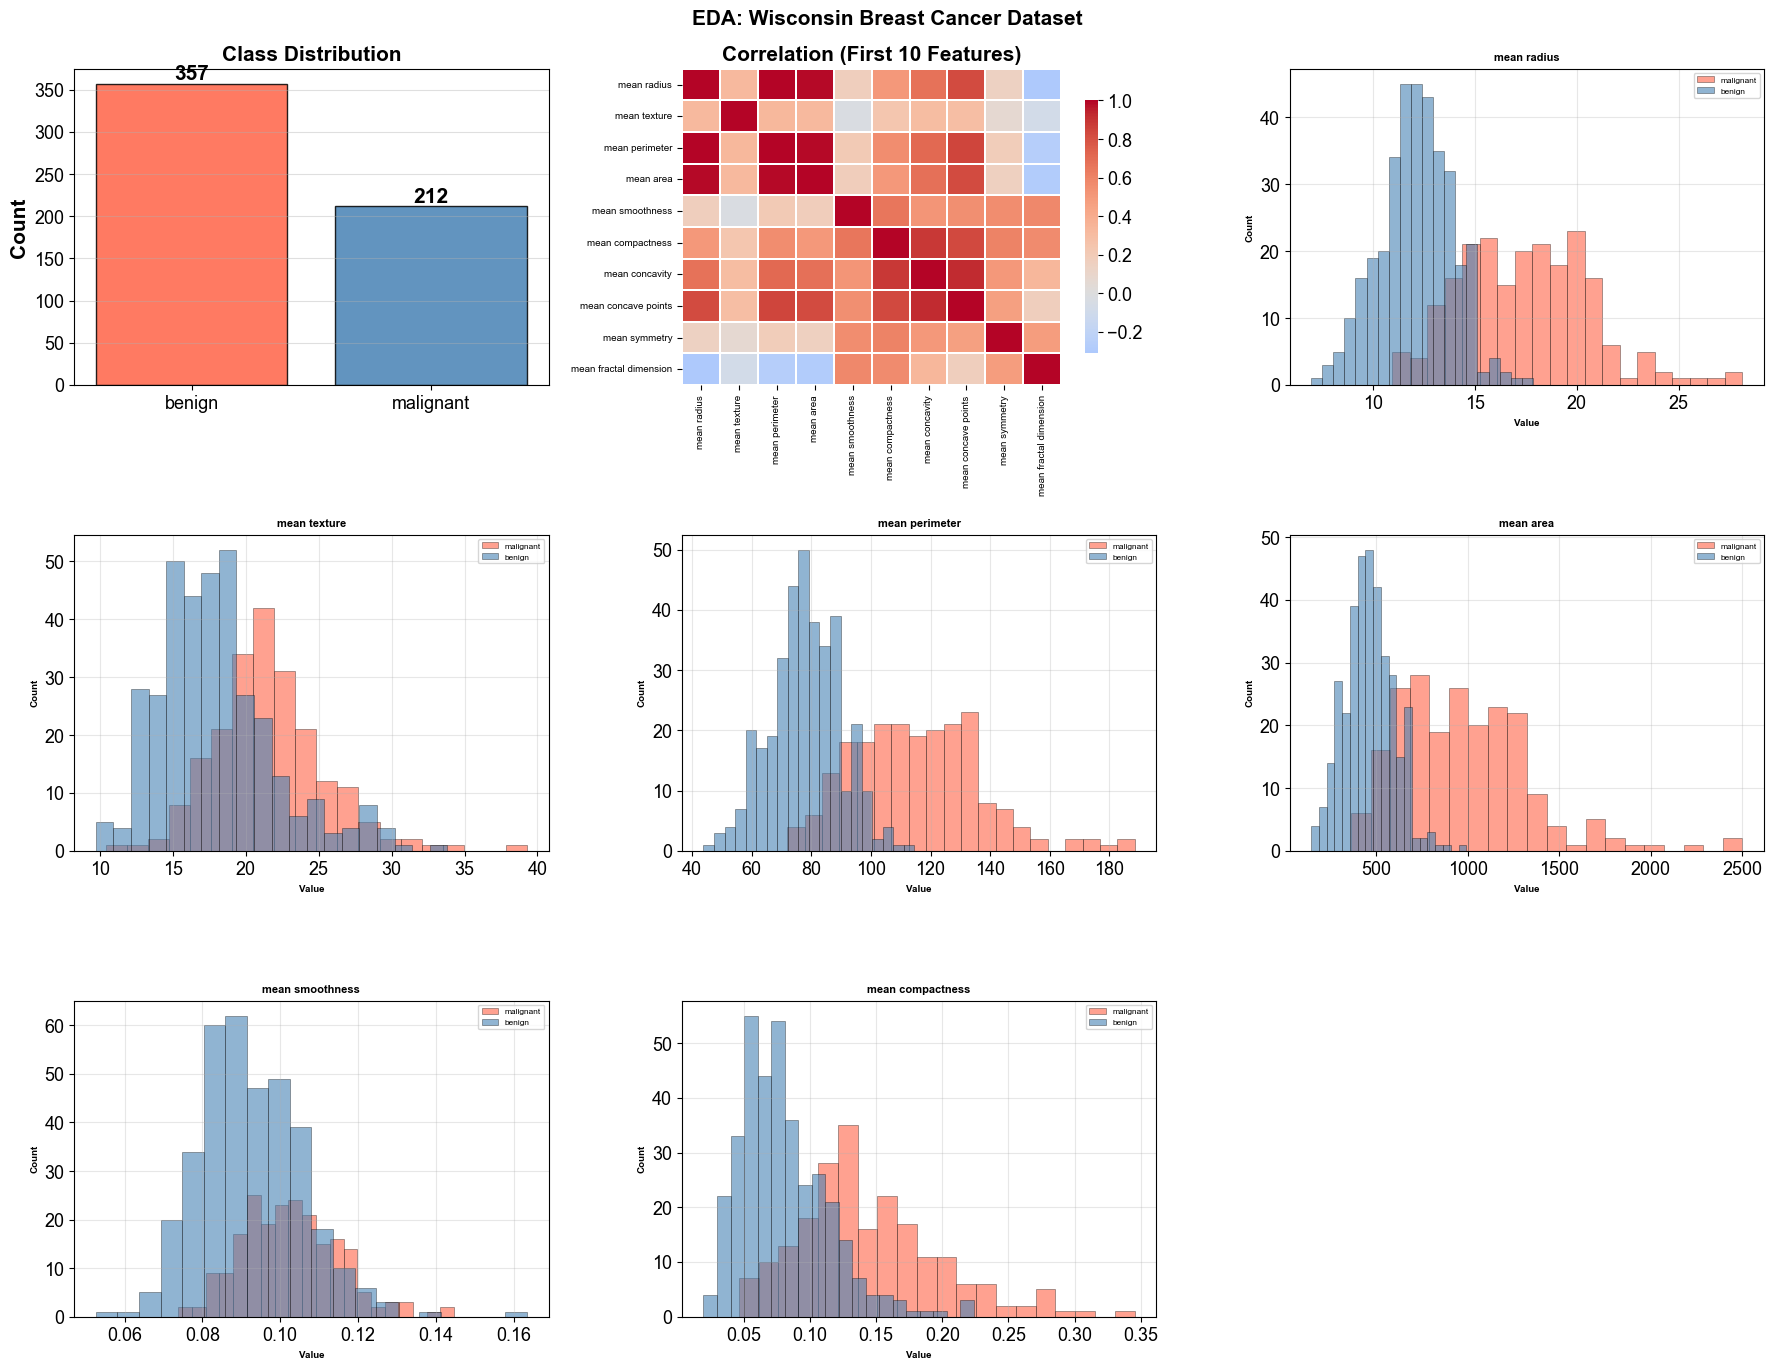

Saved: eda_analysis.png


In [54]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("EDA: Wisconsin Breast Cancer Dataset", fontsize=15, fontweight="bold")

# 2a. Class distribution
ax1 = fig.add_subplot(3, 3, 1)
counts = y_labels.value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=["tomato", "steelblue"], edgecolor="black", alpha=0.85)
ax1.set_title("Class Distribution", fontweight="bold")
ax1.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             str(val), ha="center", va="bottom", fontweight="bold")
ax1.grid(axis="y", alpha=0.4)

# 2b. Feature correlation heatmap (first 10 features)
ax2 = fig.add_subplot(3, 3, 2)
corr = X.iloc[:, :10].corr()
sns.heatmap(corr, ax=ax2, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, cbar_kws={"shrink": 0.8})
ax2.set_title("Correlation (First 10 Features)", fontweight="bold")
ax2.tick_params(axis="x", rotation=90, labelsize=7)
ax2.tick_params(axis="y", labelsize=7)

# 2c–2h. Box plots for top 6 features by class separability
top_features = X.columns[:6]
for i, feat in enumerate(top_features):
    ax = fig.add_subplot(3, 3, i + 3)
    for cls, name, color in zip([0, 1], data.target_names, ["tomato", "steelblue"]):
        vals = X.loc[y == cls, feat]
        ax.hist(vals, bins=20, alpha=0.6, color=color, label=name, edgecolor="black", linewidth=0.4)
    ax.set_title(feat[:30], fontsize=8, fontweight="bold")
    ax.set_xlabel("Value", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("eda_analysis.png", dpi=150)
plt.show()
print("Saved: eda_analysis.png")

In [55]:
# SECTION 3: PREPROCESSING & SPLIT

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [56]:
# 80-20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Train class dist : {dict(y_train.value_counts().sort_index())}")
print(f"Test  class dist : {dict(y_test.value_counts().sort_index())}")

Training samples : 455
Testing  samples : 114
Train class dist : {0: np.int64(170), 1: np.int64(285)}
Test  class dist : {0: np.int64(42), 1: np.int64(72)}


In [58]:
# 5-Fold CV splitter
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [59]:
# SECTION 4: BAGGING CLASSIFIER
# Hyperparameter grid
bagging_grid = [
    {"n_estimators": n, "max_samples": ms}
    for n in [10, 50, 100, 200]
    for ms in [0.5, 0.7, 1.0]
]

In [60]:
print("\nTable 1: Bagging Hyperparameter Evaluation")
print(f"{'n_estimators':>14} {'max_samples':>12} {'Avg CV Acc (%)':>16} {'Avg CV F1':>12}")
print("-" * 60)

best_bag_score = 0; best_bag_params = {}; bagging_results = []
for params in bagging_grid:
    clf = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=params["n_estimators"],
        max_samples=params["max_samples"],
        random_state=42, n_jobs=-1
    )
    acc_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1")
    avg_acc = acc_scores.mean() * 100
    avg_f1  = f1_scores.mean()
    bagging_results.append({**params, "acc": avg_acc, "f1": avg_f1})
    print(f"{params['n_estimators']:>14} {params['max_samples']:>12.1f} "
          f"{avg_acc:>16.2f} {avg_f1:>12.4f}")
    if avg_acc > best_bag_score:
        best_bag_score = avg_acc
        best_bag_params = params
 
print(f"\nBest Bagging Params: {best_bag_params}  |  CV Acc: {best_bag_score:.2f}%")


Table 1: Bagging Hyperparameter Evaluation
  n_estimators  max_samples   Avg CV Acc (%)    Avg CV F1
------------------------------------------------------------
            10          0.5            94.51       0.9556
            10          0.7            95.16       0.9611
            10          1.0            94.95       0.9591
            50          0.5            94.51       0.9554
            50          0.7            95.38       0.9631
            50          1.0            95.16       0.9611
           100          0.5            94.95       0.9591
           100          0.7            95.82       0.9665
           100          1.0            95.16       0.9609
           200          0.5            94.73       0.9575
           200          0.7            95.82       0.9666
           200          1.0            95.16       0.9611

Best Bagging Params: {'n_estimators': 100, 'max_samples': 0.7}  |  CV Acc: 95.82%


In [61]:
# Train final Bagging model
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=best_bag_params["n_estimators"],
    max_samples=best_bag_params["max_samples"],
    random_state=42, n_jobs=-1
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

In [62]:
# SECTION 5: BOOSTING CLASSIFIERS
# ── 5a. AdaBoost ──────────────────────────────────────────────
print("\n--- AdaBoost ---")
ada_grid = [
    {"n_estimators": n, "learning_rate": lr}
    for n in [50, 100, 200]
    for lr in [0.01, 0.1, 0.5, 1.0]
]
 
print("\nTable 2a: AdaBoost Hyperparameter Evaluation")
print(f"{'n_estimators':>14} {'learning_rate':>14} {'Avg CV Acc (%)':>16} {'Avg CV F1':>12}")
print("-" * 62)

best_ada_score = 0; best_ada_params = {}
for params in ada_grid:
    clf = AdaBoostClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        random_state=42
    )
    acc_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1")
    avg_acc = acc_scores.mean() * 100
    avg_f1  = f1_scores.mean()
    print(f"{params['n_estimators']:>14} {params['learning_rate']:>14.2f} "
          f"{avg_acc:>16.2f} {avg_f1:>12.4f}")
    if avg_acc > best_ada_score:
        best_ada_score = avg_acc
        best_ada_params = params
 
print(f"\nBest AdaBoost Params: {best_ada_params}  |  CV Acc: {best_ada_score:.2f}%")


--- AdaBoost ---

Table 2a: AdaBoost Hyperparameter Evaluation
  n_estimators  learning_rate   Avg CV Acc (%)    Avg CV F1
--------------------------------------------------------------
            50           0.01            92.53       0.9407
            50           0.10            95.38       0.9633
            50           0.50            96.70       0.9737
            50           1.00            96.70       0.9740
           100           0.01            93.41       0.9480
           100           0.10            96.04       0.9686
           100           0.50            97.36       0.9792
           100           1.00            98.02       0.9844
           200           0.01            93.63       0.9496
           200           0.10            97.14       0.9773
           200           0.50            96.92       0.9758
           200           1.00            97.80       0.9826

Best AdaBoost Params: {'n_estimators': 100, 'learning_rate': 1.0}  |  CV Acc: 98.02%


In [63]:
# ── 5b. Gradient Boosting ─────────────────────────────────────
print("\n--- Gradient Boosting ---")
gb_grid = [
    {"n_estimators": n, "learning_rate": lr, "max_depth": d}
    for n in [50, 100, 200]
    for lr in [0.05, 0.1, 0.2]
    for d in [3, 5]
]
 
print("\nTable 2b: Gradient Boosting Hyperparameter Evaluation")
print(f"{'n_est':>6} {'lr':>6} {'max_d':>7} {'Avg CV Acc (%)':>16} {'Avg CV F1':>12}")
print("-" * 55)
best_gb_score = 0; best_gb_params = {}; boosting_results = []
for params in gb_grid:
    clf = GradientBoostingClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )
    acc_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1")
    avg_acc = acc_scores.mean() * 100
    avg_f1  = f1_scores.mean()
    boosting_results.append({**params, "acc": avg_acc, "f1": avg_f1})
    print(f"{params['n_estimators']:>6} {params['learning_rate']:>6.2f} "
          f"{params['max_depth']:>7} {avg_acc:>16.2f} {avg_f1:>12.4f}")
    if avg_acc > best_gb_score:
        best_gb_score = avg_acc
        best_gb_params = params
 
print(f"\nBest Gradient Boosting Params: {best_gb_params}  |  CV Acc: {best_gb_score:.2f}%")


--- Gradient Boosting ---

Table 2b: Gradient Boosting Hyperparameter Evaluation
 n_est     lr   max_d   Avg CV Acc (%)    Avg CV F1
-------------------------------------------------------
    50   0.05       3            94.95       0.9598
    50   0.05       5            92.97       0.9436
    50   0.10       3            95.16       0.9613
    50   0.10       5            93.41       0.9468
    50   0.20       3            95.16       0.9613
    50   0.20       5            94.29       0.9544
   100   0.05       3            94.73       0.9577
   100   0.05       5            93.19       0.9453
   100   0.10       3            95.16       0.9614
   100   0.10       5            93.41       0.9470
   100   0.20       3            96.48       0.9719
   100   0.20       5            93.41       0.9473
   200   0.05       3            96.04       0.9684
   200   0.05       5            93.85       0.9507
   200   0.10       3            96.04       0.9686
   200   0.10       5         

In [64]:
# Train final Boosting models
ada_model = AdaBoostClassifier(
    n_estimators=best_ada_params["n_estimators"],
    learning_rate=best_ada_params["learning_rate"],
    random_state=42
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
 
gb_model = GradientBoostingClassifier(
    n_estimators=best_gb_params["n_estimators"],
    learning_rate=best_gb_params["learning_rate"],
    max_depth=best_gb_params["max_depth"],
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [65]:
# SECTION 6: STACKED ENSEMBLE
# Base models: SVM, Naive Bayes, Decision Tree
# Meta-learner: Logistic Regression
base_estimators = [
    ("svm",  SVC(kernel="rbf", C=1.0, probability=True, random_state=42)),
    ("nb",   GaussianNB()),
    ("dt",   DecisionTreeClassifier(max_depth=5, random_state=42)),
]
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
 
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

In [83]:
# ── Hyperparameter search space ───────────────────────────────
# We vary: SVM kernel & C, DT max_depth, meta-learner C
stacking_grid = [
    {
        "svm_kernel": "rbf",  "svm_C": 0.1,
        "dt_depth":   3,      "meta_C": 0.1,
    },
    {
        "svm_kernel": "rbf",  "svm_C": 1.0,
        "dt_depth":   3,      "meta_C": 1.0,
    },
    {
        "svm_kernel": "rbf",  "svm_C": 10.0,
        "dt_depth":   5,      "meta_C": 1.0,
    },
    {
        "svm_kernel": "linear", "svm_C": 0.1,
        "dt_depth":   3,        "meta_C": 0.1,
    },
    {
        "svm_kernel": "linear", "svm_C": 1.0,
        "dt_depth":   5,        "meta_C": 1.0,
    },
    {
        "svm_kernel": "linear", "svm_C": 10.0,
        "dt_depth":   5,        "meta_C": 10.0,
    },
    {
        "svm_kernel": "rbf",  "svm_C": 1.0,
        "dt_depth":   None,   "meta_C": 1.0,   # DT fully grown
    },
    {
        "svm_kernel": "rbf",  "svm_C": 5.0,
        "dt_depth":   7,      "meta_C": 0.5,
    },
]

In [84]:
print("\nTable 3: Stacked Ensemble Hyperparameter Evaluation (5-Fold CV)")
print(f"{'SVM kernel':>11} {'SVM C':>7} {'DT depth':>9} {'Meta C':>7} "
      f"{'Base Models':<35} {'Meta Learner':<22} {'CV Acc (%)':>12} {'CV F1':>10}")
print("-" * 115)

best_stack_score = 0
best_stack_params = {}
best_stack_acc_folds = None
best_stack_f1_folds  = None
stacking_results = []
 
for params in stacking_grid:
    # Build base estimators with current hyperparams
    base_estimators_search = [
        ("svm", SVC(
            kernel=params["svm_kernel"],
            C=params["svm_C"],
            probability=True,
            random_state=42
        )),
        ("nb",  GaussianNB()),
        ("dt",  DecisionTreeClassifier(
            max_depth=params["dt_depth"],
            random_state=42
        )),
    ]
    meta = LogisticRegression(
        C=params["meta_C"],
        max_iter=1000,
        random_state=42
    )
    clf = StackingClassifier(
        estimators=base_estimators_search,
        final_estimator=meta,
        cv=5,
        stack_method="predict_proba",
        n_jobs=-1
    )
 
    acc_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy")
    f1_scores  = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1")
    avg_acc = acc_scores.mean() * 100
    avg_f1  = f1_scores.mean()
 
    depth_str = str(params["dt_depth"]) if params["dt_depth"] else "None"
    base_str  = f"SVM({params['svm_kernel']}) + NB + DT(d={depth_str})"
    meta_str  = f"LR(C={params['meta_C']})"
 
    stacking_results.append({**params, "acc": avg_acc, "f1": avg_f1,
                              "base_str": base_str, "meta_str": meta_str,
                              "acc_folds": acc_scores, "f1_folds": f1_scores})
 
    print(f"{params['svm_kernel']:>11} {params['svm_C']:>7.1f} {depth_str:>9} "
          f"{params['meta_C']:>7.1f} {base_str:<35} {meta_str:<22} "
          f"{avg_acc:>12.2f} {avg_f1:>10.4f}")
 
    if avg_acc > best_stack_score:
        best_stack_score  = avg_acc
        best_stack_params = params
        best_stack_acc_folds = acc_scores
        best_stack_f1_folds  = f1_scores
        best_base_str = base_str
        best_meta_str = meta_str


Table 3: Stacked Ensemble Hyperparameter Evaluation (5-Fold CV)
 SVM kernel   SVM C  DT depth  Meta C Base Models                         Meta Learner             CV Acc (%)      CV F1
-------------------------------------------------------------------------------------------------------------------
        rbf     0.1         3     0.1 SVM(rbf) + NB + DT(d=3)             LR(C=0.1)                     94.51     0.9568
        rbf     1.0         3     1.0 SVM(rbf) + NB + DT(d=3)             LR(C=1.0)                     95.82     0.9667
        rbf    10.0         5     1.0 SVM(rbf) + NB + DT(d=5)             LR(C=1.0)                     96.70     0.9738
     linear     0.1         3     0.1 SVM(linear) + NB + DT(d=3)          LR(C=0.1)                     96.04     0.9689
     linear     1.0         5     1.0 SVM(linear) + NB + DT(d=5)          LR(C=1.0)                     96.04     0.9687
     linear    10.0         5    10.0 SVM(linear) + NB + DT(d=5)          LR(C=10.0)         

In [69]:
# Print best configuration
print(f"\n{'─'*65}")
print(f"Best Stacking Config:")
print(f"  SVM kernel  : {best_stack_params['svm_kernel']}")
print(f"  SVM C       : {best_stack_params['svm_C']}")
print(f"  DT max_depth: {best_stack_params['dt_depth']}")
print(f"  Meta LR C   : {best_stack_params['meta_C']}")
print(f"  CV Accuracy : {best_stack_score:.2f}%")
print(f"  Per-fold Acc: {[f'{v*100:.2f}%' for v in best_stack_acc_folds]}")
print(f"  Mean ± Std  : {best_stack_acc_folds.mean()*100:.2f}% ± {best_stack_acc_folds.std()*100:.2f}%")
print(f"{'─'*65}")


─────────────────────────────────────────────────────────────────
Best Stacking Config:
  SVM kernel  : rbf
  SVM C       : 5.0
  DT max_depth: 7
  Meta LR C   : 0.5
  CV Accuracy : 96.92%
  Per-fold Acc: ['96.70%', '97.80%', '93.41%', '97.80%', '98.90%']
  Mean ± Std  : 96.92% ± 1.89%
─────────────────────────────────────────────────────────────────


In [70]:
# ── Train final Stacking model with best hyperparams ─────────
best_base_estimators = [
    ("svm", SVC(
        kernel=best_stack_params["svm_kernel"],
        C=best_stack_params["svm_C"],
        probability=True,
        random_state=42
    )),
    ("nb",  GaussianNB()),
    ("dt",  DecisionTreeClassifier(
        max_depth=best_stack_params["dt_depth"],
        random_state=42
    )),
]
best_meta = LogisticRegression(
    C=best_stack_params["meta_C"],
    max_iter=1000,
    random_state=42
)
stacking_model = StackingClassifier(
    estimators=best_base_estimators,
    final_estimator=best_meta,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
 
stack_acc = best_stack_acc_folds
stack_f1  = best_stack_f1_folds
 
print(f"\nFinal Stacking model trained with best hyperparameters.")
print(f"Test set predictions generated.")


Final Stacking model trained with best hyperparameters.
Test set predictions generated.


In [71]:
# SECTION 7: PERFORMANCE COMPARISON (TABLE 4)

def get_metrics(y_true, y_pred, name):
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1 Score":  f1_score(y_true, y_pred, zero_division=0),
    }
 
# Use best boosting model (higher of AdaBoost vs GB)
if best_ada_score >= best_gb_score:
    y_pred_boost = y_pred_ada
    boost_name   = f"AdaBoost (n={best_ada_params['n_estimators']}, lr={best_ada_params['learning_rate']})"
else:
    y_pred_boost = y_pred_gb
    boost_name   = f"Gradient Boosting (n={best_gb_params['n_estimators']}, lr={best_gb_params['learning_rate']})"

In [72]:
results_list = [
    get_metrics(y_test, y_pred_bag,   f"Bagging (n={best_bag_params['n_estimators']})"),
    get_metrics(y_test, y_pred_boost,  boost_name),
    get_metrics(y_test, y_pred_stack, "Stacked Ensemble"),
]
results_df = pd.DataFrame(results_list).set_index("Model")
 
print("\nTable 4: Performance Comparison of Ensemble Models")
print(f"{'Model':<45} {'Accuracy (%)':>13} {'Precision':>11} {'Recall':>8} {'F1 Score':>10}")
print("-" * 93)
for model, row in results_df.iterrows():
    print(f"{model:<45} {row['Accuracy']:>13.2f} {row['Precision']:>11.4f} "
          f"{row['Recall']:>8.4f} {row['F1 Score']:>10.4f}")


Table 4: Performance Comparison of Ensemble Models
Model                                          Accuracy (%)   Precision   Recall   F1 Score
---------------------------------------------------------------------------------------------
Bagging (n=100)                                       94.74      0.9583   0.9583     0.9583
AdaBoost (n=100, lr=1.0)                              95.61      0.9467   0.9861     0.9660
Stacked Ensemble                                      98.25      0.9730   1.0000     0.9863


In [73]:
# Detailed classification reports
for name, y_pred in [("Bagging", y_pred_bag),
                     ("Boosting", y_pred_boost),
                     ("Stacked Ensemble", y_pred_stack)]:
    print(f"\n--- Classification Report: {name} ---")
    print(classification_report(y_test, y_pred,
                                target_names=data.target_names, zero_division=0))


--- Classification Report: Bagging ---
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Classification Report: Boosting ---
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Classification Report: Stacked Ensemble ---
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       11

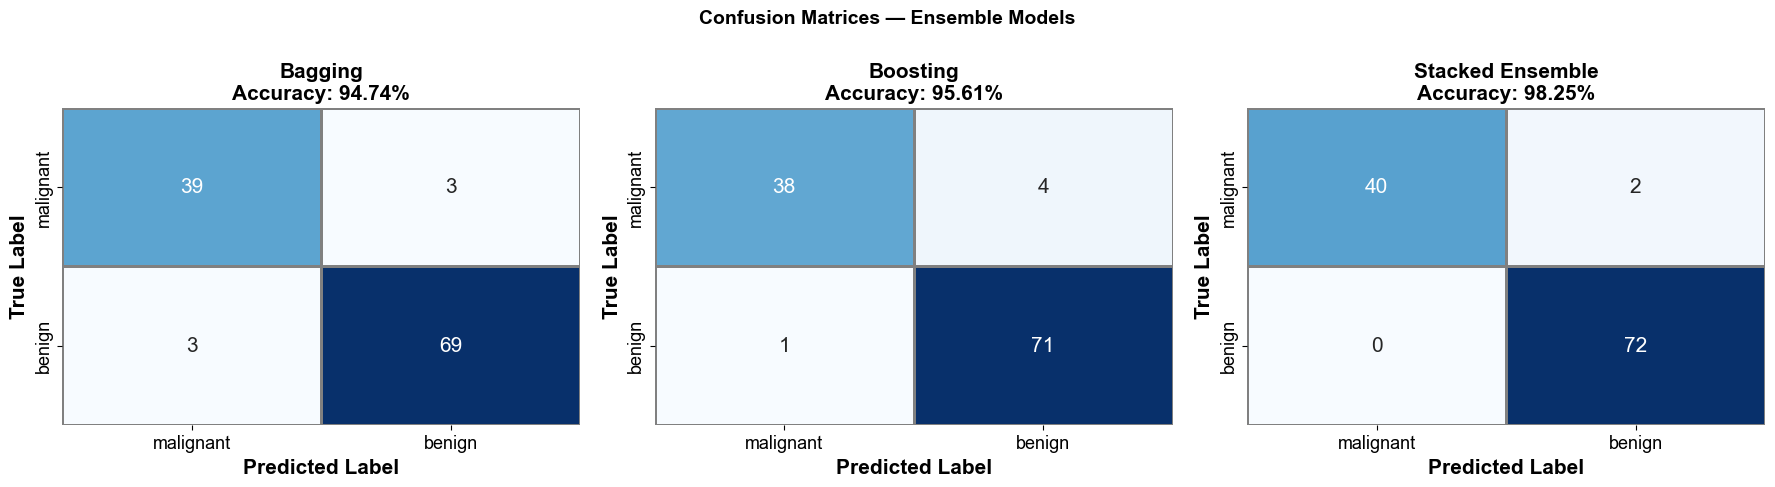

Saved: confusion_matrices.png


In [74]:
# SECTION 8: VISUALIZATIONS
# ── 8a. Confusion Matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_preds = [
    ("Bagging",          y_pred_bag),
    ("Boosting",         y_pred_boost),
    ("Stacked Ensemble", y_pred_stack),
]
for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=data.target_names, yticklabels=data.target_names,
                linewidths=1, linecolor="gray", cbar=False)
    acc = accuracy_score(y_test, y_pred) * 100
    ax.set_title(f"{name}\nAccuracy: {acc:.2f}%", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
plt.suptitle("Confusion Matrices — Ensemble Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

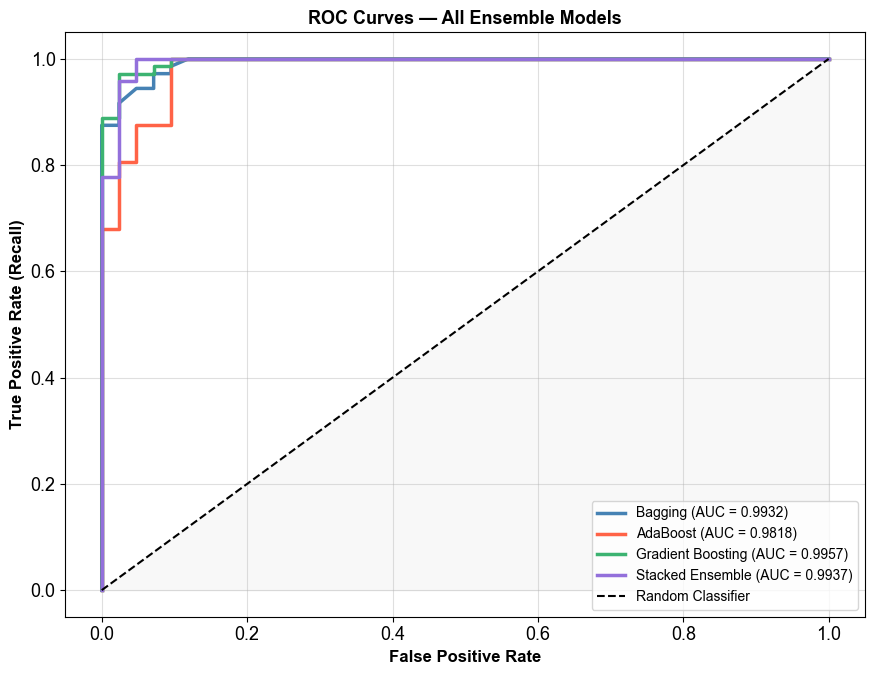

Saved: roc_curves.png


In [75]:
# ── 8b. ROC Curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple", "darkorange"]
roc_models = [
    ("Bagging",              bagging_model),
    ("AdaBoost",             ada_model),
    ("Gradient Boosting",    gb_model),
    ("Stacked Ensemble",     stacking_model),
]
for (name, model), color in zip(roc_models, colors):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {roc_auc:.4f})")
 
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.set_title("ROC Curves — All Ensemble Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("Saved: roc_curves.png")

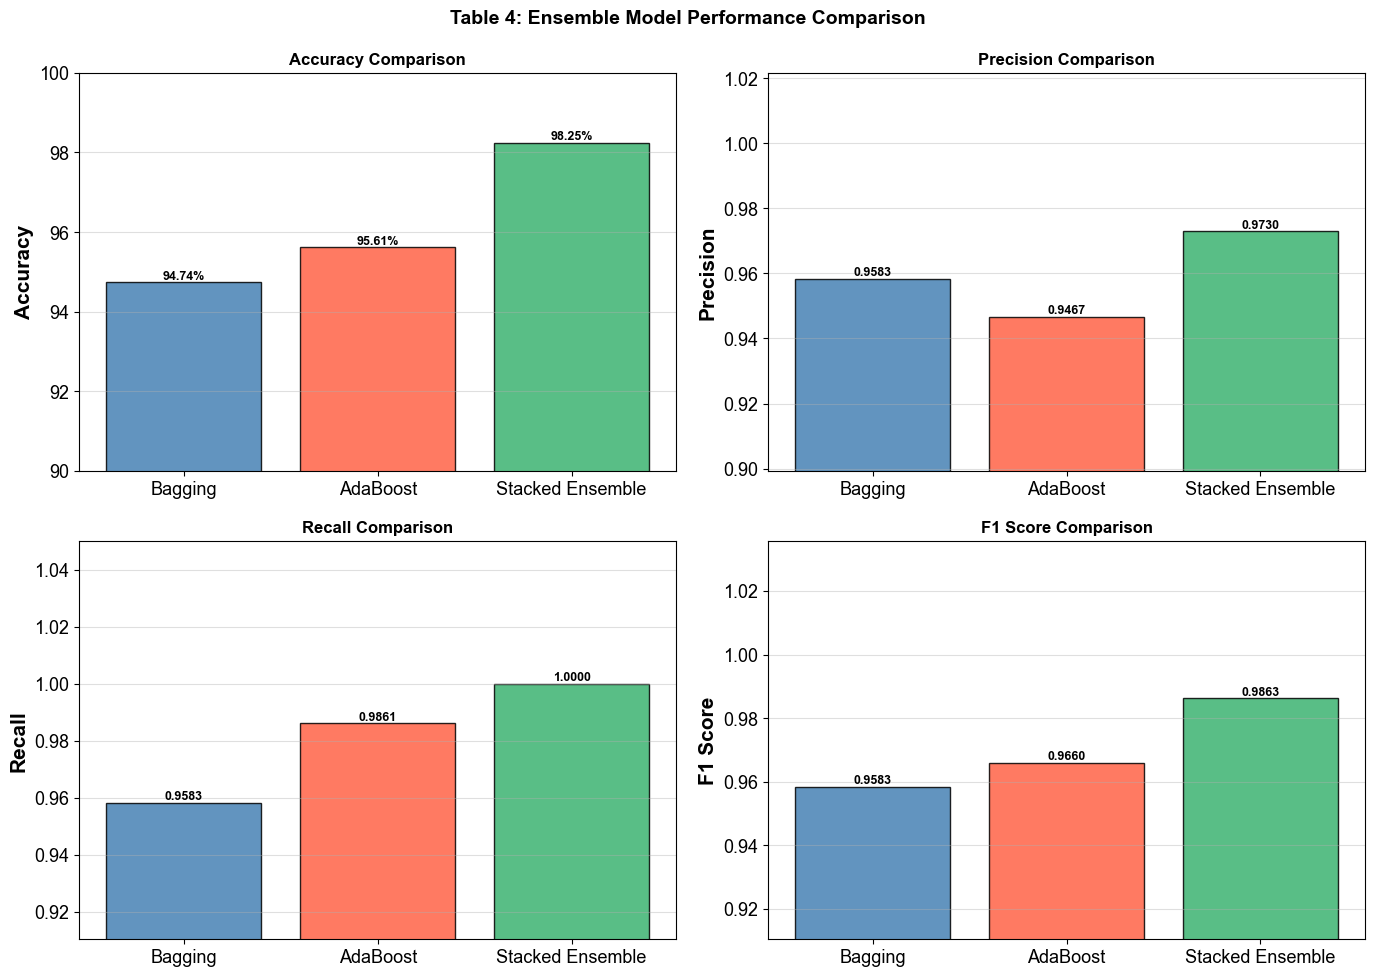

Saved: metrics_comparison.png


In [76]:
# ── 8c. Metrics Bar Chart ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
model_names = [m.split(" (")[0] for m in results_df.index]
bar_colors = ["steelblue", "tomato", "mediumseagreen"]
 
for ax, metric in zip(axes.flat, metrics):
    vals = results_df[metric].values
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"{metric} Comparison", fontweight="bold", fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim([min(vals) * 0.95, min(max(vals) * 1.05, 100 if metric == "Accuracy" else 1.05)])
    ax.grid(axis="y", alpha=0.4)
    for bar, val in zip(bars, vals):
        label = f"{val:.2f}%" if metric == "Accuracy" else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")
 
plt.suptitle("Table 4: Ensemble Model Performance Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()
print("Saved: metrics_comparison.png")

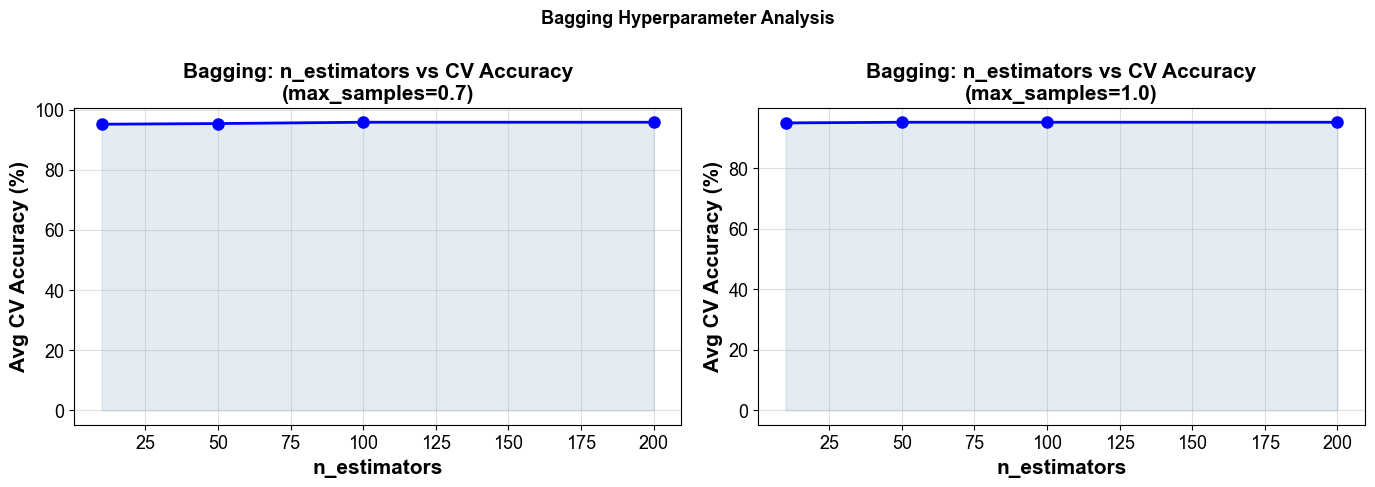

Saved: bagging_hyperparams.png


In [77]:
# ── 8d. Bagging: n_estimators vs Accuracy ────────────────────
bag_df = pd.DataFrame(bagging_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, ms in zip(axes, [0.7, 1.0]):
    sub = bag_df[bag_df["max_samples"] == ms]
    ax.plot(sub["n_estimators"], sub["acc"], "bo-", linewidth=2, markersize=8)
    ax.fill_between(sub["n_estimators"], sub["acc"], alpha=0.15, color="steelblue")
    ax.set_title(f"Bagging: n_estimators vs CV Accuracy\n(max_samples={ms})",
                 fontweight="bold")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("Avg CV Accuracy (%)")
    ax.grid(alpha=0.4)
 
plt.suptitle("Bagging Hyperparameter Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bagging_hyperparams.png", dpi=150)
plt.show()
print("Saved: bagging_hyperparams.png")

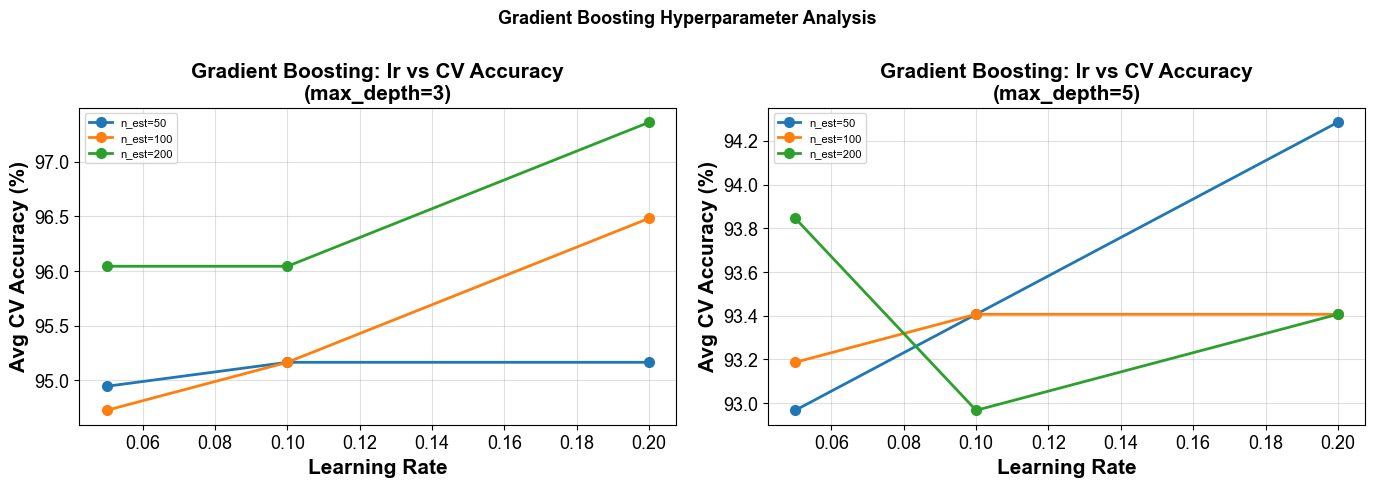

Saved: boosting_hyperparams.png


In [78]:
# ── 8e. Boosting: learning_rate vs Accuracy ──────────────────
gb_df = pd.DataFrame(boosting_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, depth in zip(axes, [3, 5]):
    sub = gb_df[gb_df["max_depth"] == depth]
    for n_est in sub["n_estimators"].unique():
        line_data = sub[sub["n_estimators"] == n_est]
        ax.plot(line_data["learning_rate"], line_data["acc"],
                "o-", linewidth=2, markersize=7, label=f"n_est={n_est}")
    ax.set_title(f"Gradient Boosting: lr vs CV Accuracy\n(max_depth={depth})",
                 fontweight="bold")
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Avg CV Accuracy (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
 
plt.suptitle("Gradient Boosting Hyperparameter Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("boosting_hyperparams.png", dpi=150)
plt.show()
print("Saved: boosting_hyperparams.png")

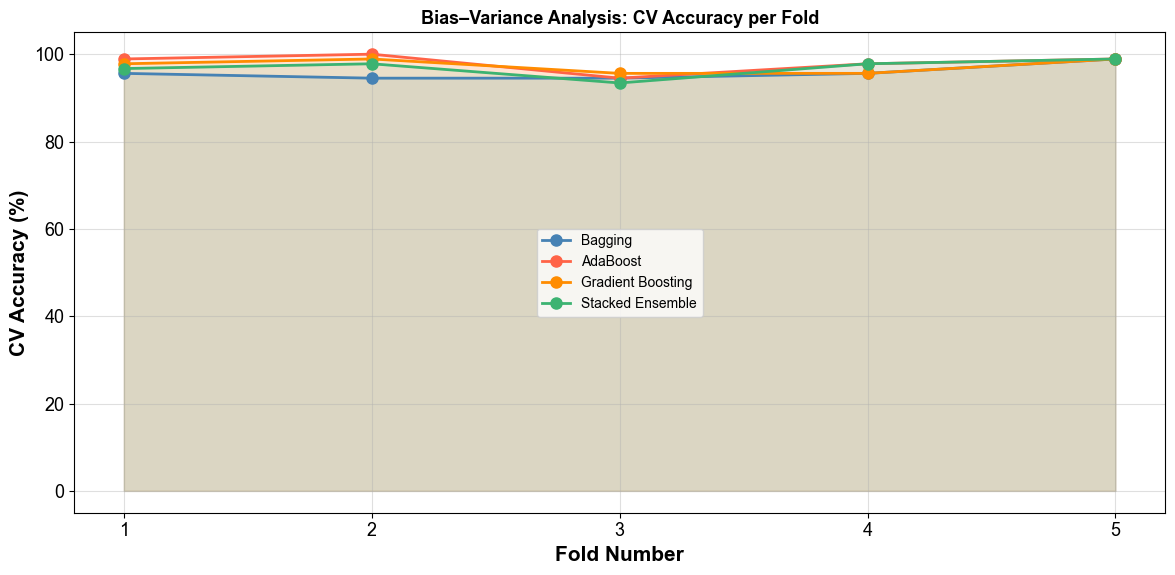

Saved: bias_variance_cv.png


In [79]:
# ── 8f. Bias–Variance Analysis (CV fold spread) ───────────────
fig, ax = plt.subplots(figsize=(12, 6))
 
bag_cv   = cross_val_score(bagging_model,  X_train, y_train, cv=skf, scoring="accuracy") * 100
ada_cv   = cross_val_score(ada_model,      X_train, y_train, cv=skf, scoring="accuracy") * 100
gb_cv    = cross_val_score(gb_model,       X_train, y_train, cv=skf, scoring="accuracy") * 100
stack_cv = cross_val_score(stacking_model, X_train, y_train, cv=skf, scoring="accuracy") * 100
 
folds = [1, 2, 3, 4, 5]
for scores, name, color in [
    (bag_cv,   "Bagging",          "steelblue"),
    (ada_cv,   "AdaBoost",         "tomato"),
    (gb_cv,    "Gradient Boosting","darkorange"),
    (stack_cv, "Stacked Ensemble", "mediumseagreen"),
]:
    ax.plot(folds, scores, "o-", color=color, linewidth=2, markersize=8, label=name)
    ax.fill_between(folds, scores, alpha=0.1, color=color)
 
ax.set_title("Bias–Variance Analysis: CV Accuracy per Fold",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fold Number")
ax.set_ylabel("CV Accuracy (%)")
ax.set_xticks(folds)
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("bias_variance_cv.png", dpi=150)
plt.show()
print("Saved: bias_variance_cv.png")

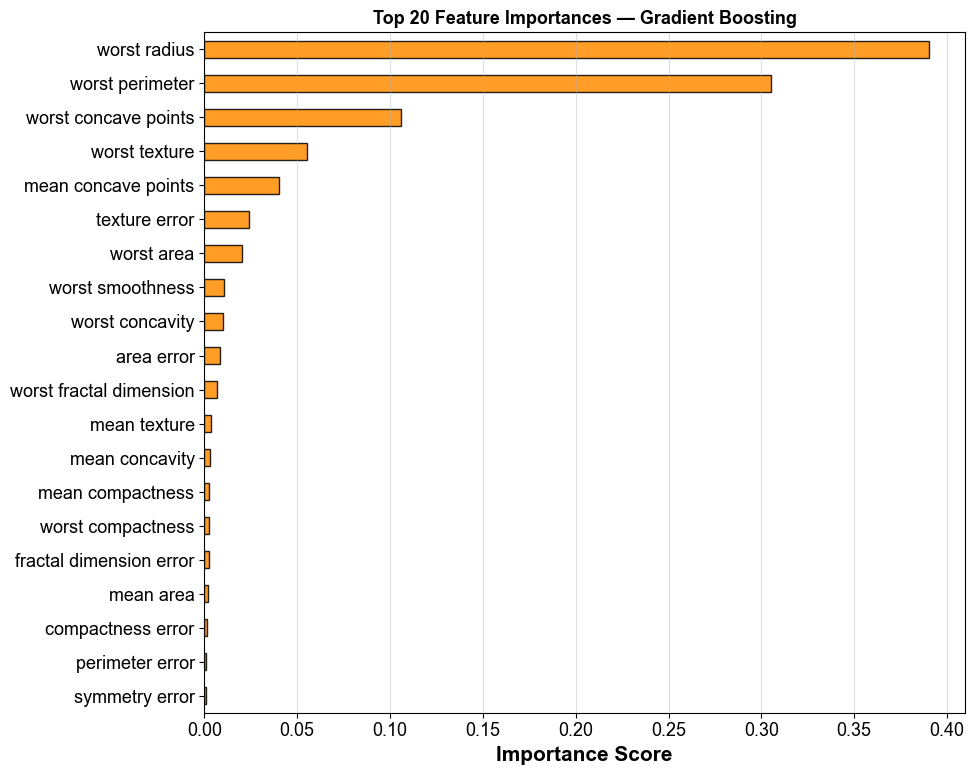

Saved: feature_importances.png


In [80]:
# ── 8g. Feature Importances (Gradient Boosting) ───────────────
fig, ax = plt.subplots(figsize=(10, 8))
importances = pd.Series(gb_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(20).plot(
    kind="barh", ax=ax, color="darkorange", edgecolor="black", alpha=0.85
)
ax.set_title("Top 20 Feature Importances — Gradient Boosting",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()
print("Saved: feature_importances.png")

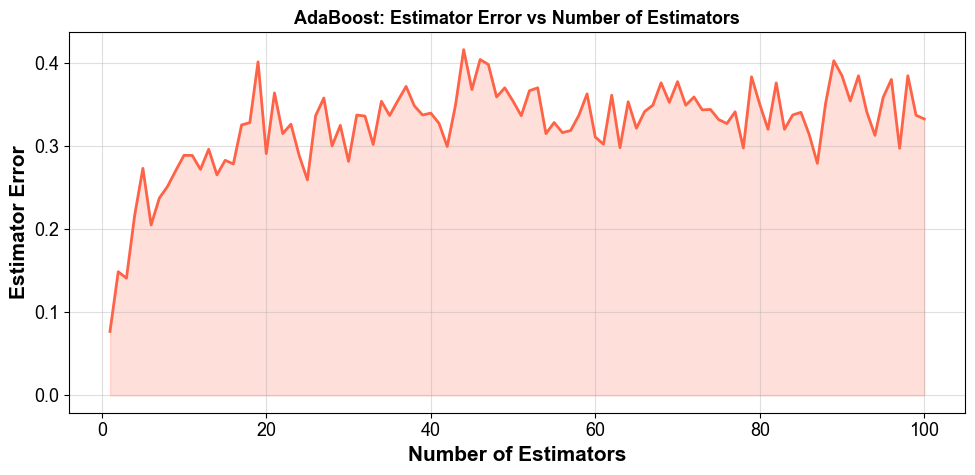

Saved: adaboost_error_curve.png


In [81]:
# ── 8h. AdaBoost: Estimator error curve ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ada_errors = [err for err in ada_model.estimator_errors_]
ax.plot(range(1, len(ada_errors)+1), ada_errors, "tomato", linewidth=2)
ax.fill_between(range(1, len(ada_errors)+1), ada_errors, alpha=0.2, color="tomato")
ax.set_title("AdaBoost: Estimator Error vs Number of Estimators",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Estimator Error")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("adaboost_error_curve.png", dpi=150)
plt.show()
print("Saved: adaboost_error_curve.png")

In [82]:
# ============================================================
# SECTION 9: SUMMARY TABLES & OBSERVATIONS
# ============================================================
 
print("\n" + "=" * 65)
print("STEP 9: FINAL SUMMARY")
print("=" * 65)
 
best_model = results_df["Accuracy"].idxmax().split(" (")[0]
print(f"\nBest performing model : {best_model}")
 
print(f"""
Observation Questions:
──────────────────────────────────────────────────────────────
 
Q1. How does Bagging reduce variance?
    → Bagging trains {best_bag_params['n_estimators']} Decision Trees on different bootstrap samples
      (max_samples={best_bag_params['max_samples']}) and averages their predictions.
      Individual trees overfit to their sample; averaging cancels out
      random errors, reducing overall variance without increasing bias.
 
Q2. How does Boosting address model bias?
    → AdaBoost/Gradient Boosting train estimators sequentially. Each new
      tree focuses on samples the previous ensemble misclassified (higher
      weights in AdaBoost; negative gradient in GB). This iteratively
      corrects systematic errors, reducing bias. Best GB params:
      n_est={best_gb_params['n_estimators']}, lr={best_gb_params['learning_rate']}, max_depth={best_gb_params['max_depth']}.
 
Q3. Why does stacking benefit from heterogeneous models?
    → SVM captures non-linear margin boundaries, Naive Bayes provides
      probabilistic feature independence assumptions, Decision Tree
      captures feature interactions. Each learns a different representation.
      The meta-learner (Logistic Regression) learns the optimal linear
      combination of their outputs, exploiting complementary strengths.
 
Q4. Which ensemble method performed best and why?
    → {best_model} achieved the highest test accuracy of
      {results_df['Accuracy'].max():.2f}%.
 
Bias–Variance Summary:
  Bagging           → LOW variance,  similar bias   (parallel training)
  Boosting          → LOW bias,      some variance  (sequential correction)
  Stacked Ensemble  → LOW bias+var   (diverse learners + meta-learner)
──────────────────────────────────────────────────────────────
""")


STEP 9: FINAL SUMMARY

Best performing model : Stacked Ensemble

Observation Questions:
──────────────────────────────────────────────────────────────

Q1. How does Bagging reduce variance?
    → Bagging trains 100 Decision Trees on different bootstrap samples
      (max_samples=0.7) and averages their predictions.
      Individual trees overfit to their sample; averaging cancels out
      random errors, reducing overall variance without increasing bias.

Q2. How does Boosting address model bias?
    → AdaBoost/Gradient Boosting train estimators sequentially. Each new
      tree focuses on samples the previous ensemble misclassified (higher
      weights in AdaBoost; negative gradient in GB). This iteratively
      corrects systematic errors, reducing bias. Best GB params:
      n_est=200, lr=0.2, max_depth=3.

Q3. Why does stacking benefit from heterogeneous models?
    → SVM captures non-linear margin boundaries, Naive Bayes provides
      probabilistic feature independence assumpti